<a href="https://colab.research.google.com/github/MuzaffarIshmurotov/IDSC2026-Glaucoma-Detection/blob/main/Hillel_Yaffe_Glaucoma_Dataset_(HYGD)_A_Gold_Standard_Annotated_Fundus_Dataset_for_Glaucoma_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision timm pandas pillow scikit-learn matplotlib seaborn grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 51.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=6430fab1bbccc0fb00f7ef4b492abc22eb80baa4ccc5145aa6de2f7b4538839c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
from google.colab import files
uploaded = files.upload()

Saving hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0.zip to hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0.zip


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
print(os.listdir('/content/drive/MyDrive/'))

['Documents  (1)', 'Python Course content.pdf', 'Poster GLOVISCO.pdf.pdf', 'Quiz 1 Statel.pdf', 'functional text(2).pdf', 'eSOC.txt', 'power_off_reset_reason.txt', 'shutdown_profile.1.txt', 'shutdown_profile_latest.txt', 'SF_Dump.txt', 'shutdown_profile.2.txt', 'shutdown_profile.3.txt', 'shutdown_profile.4.txt', 'shutdown_profile.5.txt', 'power_off_reset_reason_backup.txt', 'lom_log.txt', 'iwc_dump.txt', 'iwc_dump_old.txt', 'PreloadInstaller.txt', 'pm_debug_info.txt', 'setupwizard.txt', 'vrrinfo.txt', 'Firstbootlog.txt', 'home_fota_update_log.txt', 'settingsprovider.txt', 'mrsi_log.txt', 'latihan soal distribusi freq.pdf', 'LinkAja_RECEIPT_2409255_150924.pdf', 'Linda Gilbert-Elements of Modern Algebra-Cengage Learning (2014).pdf', 'RPS KPB (2024) - Updated-1.pdf', 'team_division.csv', 'feismo.com-probability-and-statistics-for-engineers-and-scientist-9th-edition-by-walpole-pr_8c2f1cd0e805b38ef9dc8522262b91fd (1).pdf', 'RPS 2024.pdf', 'Module Handbook PSA I (1).pdf', 'Slide - Flow Contr

In [5]:
import os
print(os.listdir('/content/drive/MyDrive/'))

['Documents  (1)', 'Python Course content.pdf', 'Poster GLOVISCO.pdf.pdf', 'Quiz 1 Statel.pdf', 'functional text(2).pdf', 'eSOC.txt', 'power_off_reset_reason.txt', 'shutdown_profile.1.txt', 'shutdown_profile_latest.txt', 'SF_Dump.txt', 'shutdown_profile.2.txt', 'shutdown_profile.3.txt', 'shutdown_profile.4.txt', 'shutdown_profile.5.txt', 'power_off_reset_reason_backup.txt', 'lom_log.txt', 'iwc_dump.txt', 'iwc_dump_old.txt', 'PreloadInstaller.txt', 'pm_debug_info.txt', 'setupwizard.txt', 'vrrinfo.txt', 'Firstbootlog.txt', 'home_fota_update_log.txt', 'settingsprovider.txt', 'mrsi_log.txt', 'latihan soal distribusi freq.pdf', 'LinkAja_RECEIPT_2409255_150924.pdf', 'Linda Gilbert-Elements of Modern Algebra-Cengage Learning (2014).pdf', 'RPS KPB (2024) - Updated-1.pdf', 'team_division.csv', 'feismo.com-probability-and-statistics-for-engineers-and-scientist-9th-edition-by-walpole-pr_8c2f1cd0e805b38ef9dc8522262b91fd (1).pdf', 'RPS 2024.pdf', 'Module Handbook PSA I (1).pdf', 'Slide - Flow Contr

In [6]:
import zipfile
import os

print(os.listdir('/content/drive/MyDrive/Competition/'))

['hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0.zip']


In [7]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Competition/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/HYGD')

print("✅ Done!")

✅ Done!


In [8]:
# See what's inside the extracted folder
print(os.listdir('/content/HYGD/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0'))

['LICENSE.txt', 'SHA256SUMS.txt', 'Images', 'Labels.csv', 'README.md']


In [9]:
base_path = '/content/HYGD/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0'

print("Total images:", len(os.listdir(f'{base_path}/Images')))

Total images: 747


In [10]:
import pandas as pd

df = pd.read_csv(f'{base_path}/Labels.csv')
print(df.head(10))
print("\nShape:", df.shape)
print("\nLabel distribution:")
print(df['Label'].value_counts())

  Image Name  Patient Label  Quality Score  Unnamed: 4
0    0_0.jpg        0  GON+           6.18         NaN
1    1_0.jpg        1  GON+           5.31         NaN
2    1_1.jpg        1  GON+           4.37         NaN
3    2_0.jpg        2  GON+           3.51         NaN
4    2_1.jpg        2  GON+           4.24         NaN
5    3_0.jpg        3  GON+           5.95         NaN
6    3_1.jpg        3  GON+           4.22         NaN
7    4_0.jpg        4  GON+           5.25         NaN
8    5_0.jpg        5  GON+           6.58         NaN
9    5_1.jpg        5  GON+           6.67         NaN

Shape: (747, 5)

Label distribution:
Label
GON+    548
GON-    199
Name: count, dtype: int64


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [12]:
base_path = '/content/HYGD/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0'
images_path = f'{base_path}/Images'

df = pd.read_csv(f'{base_path}/Labels.csv')
df = df[['Image Name', 'Label', 'Quality Score']].dropna(subset=['Image Name', 'Label'])

# Convert labels to numbers: GON+ = 1, GON- = 0
df['label_num'] = (df['Label'] == 'GON+').astype(int)

print(df.head())
print("\nClass distribution:")
print(df['label_num'].value_counts())

  Image Name Label  Quality Score  label_num
0    0_0.jpg  GON+           6.18          1
1    1_0.jpg  GON+           5.31          1
2    1_1.jpg  GON+           4.37          1
3    2_0.jpg  GON+           3.51          1
4    2_1.jpg  GON+           4.24          1

Class distribution:
label_num
1    548
0    199
Name: count, dtype: int64


In [13]:
# Split by image (simple split for now)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label_num'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label_num'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 522 | Val: 112 | Test: 113


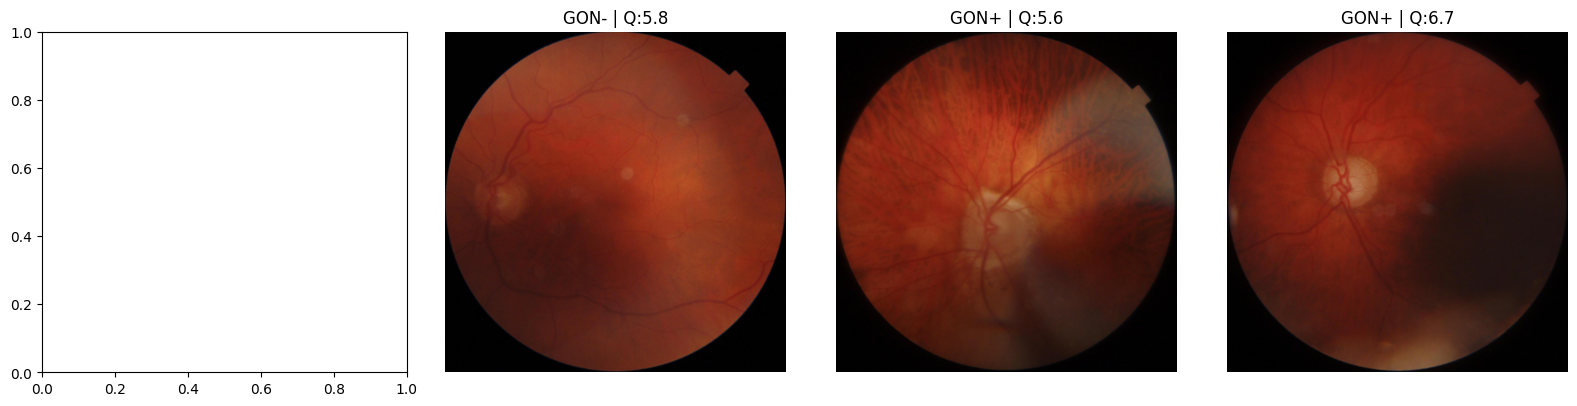

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, row in df.sample(4, random_state=1).iterrows():
    img = Image.open(f"{images_path}/{row['Image Name']}")
    axes[i % 4].imshow(img)
    axes[i % 4].set_title(f"{row['Label']} | Q:{row['Quality Score']:.1f}")
    axes[i % 4].axis('off')
plt.tight_layout()
plt.show()

In [15]:
class GlaucomaDataset(Dataset):
    def __init__(self, dataframe, images_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.images_dir}/{row['Image Name']}").convert('RGB')
        label = row['label_num']
        if self.transform:
            img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = GlaucomaDataset(train_df, images_path, transform=train_transform)
val_dataset   = GlaucomaDataset(val_df,   images_path, transform=val_transform)
test_dataset  = GlaucomaDataset(test_df,  images_path, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print("✅ Datasets ready!")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

✅ Datasets ready!
Train batches: 33 | Val batches: 7 | Test batches: 8


In [16]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load pretrained EfficientNet
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=2)
model = model.to(device)
print("✅ Model loaded!")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ Model loaded!


In [17]:
# Class weights to handle imbalance (199 vs 548)
class_weights = torch.tensor([548/199, 1.0]).to(device)  # higher weight for minority class
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("✅ Loss function and optimizer ready!")

✅ Loss function and optimizer ready!


In [18]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels

print("✅ Training functions defined!")

✅ Training functions defined!


In [19]:
NUM_EPOCHS = 10
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/best_model.pth')
        saved = "💾 Saved!"
    else:
        saved = ""

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} {saved}")

print("\n✅ Training complete!")

Epoch 1/10 | Train Loss: 1.2577 Acc: 0.732 | Val Loss: 0.5748 Acc: 0.804 💾 Saved!
Epoch 2/10 | Train Loss: 0.3231 Acc: 0.897 | Val Loss: 0.3066 Acc: 0.857 💾 Saved!
Epoch 3/10 | Train Loss: 0.3718 Acc: 0.910 | Val Loss: 0.1605 Acc: 0.929 💾 Saved!
Epoch 4/10 | Train Loss: 0.3616 Acc: 0.918 | Val Loss: 0.1765 Acc: 0.938 
Epoch 5/10 | Train Loss: 0.2409 Acc: 0.937 | Val Loss: 0.0976 Acc: 0.955 💾 Saved!
Epoch 6/10 | Train Loss: 0.2092 Acc: 0.950 | Val Loss: 0.1469 Acc: 0.955 
Epoch 7/10 | Train Loss: 0.1693 Acc: 0.943 | Val Loss: 0.1395 Acc: 0.955 
Epoch 8/10 | Train Loss: 0.0811 Acc: 0.969 | Val Loss: 0.1723 Acc: 0.938 
Epoch 9/10 | Train Loss: 0.0963 Acc: 0.969 | Val Loss: 0.1241 Acc: 0.946 
Epoch 10/10 | Train Loss: 0.1081 Acc: 0.969 | Val Loss: 0.0918 Acc: 0.955 💾 Saved!

✅ Training complete!


In [21]:
# Load the best saved model
model.load_state_dict(torch.load('/content/best_model.pth'))

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['GON-', 'GON+']))
print(f"\nAUC-ROC: {roc_auc_score(test_labels, test_preds):.4f}")

Test Accuracy: 0.9381
Test Loss: 0.1867

Classification Report:
              precision    recall  f1-score   support

        GON-       0.87      0.90      0.89        30
        GON+       0.96      0.95      0.96        83

    accuracy                           0.94       113
   macro avg       0.92      0.93      0.92       113
weighted avg       0.94      0.94      0.94       113


AUC-ROC: 0.9259


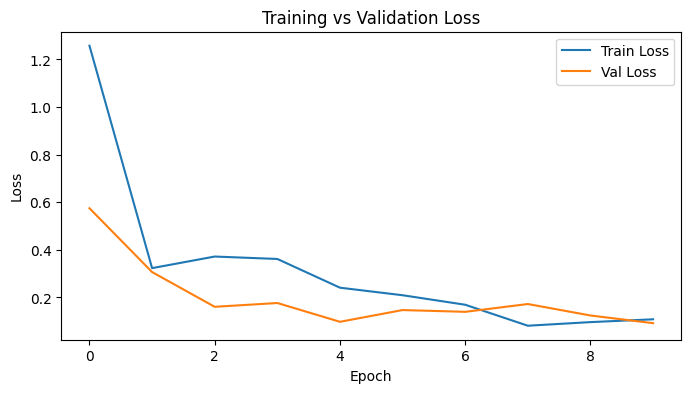

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [23]:
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
import cv2

print("✅ Grad-CAM ready!")

✅ Grad-CAM ready!


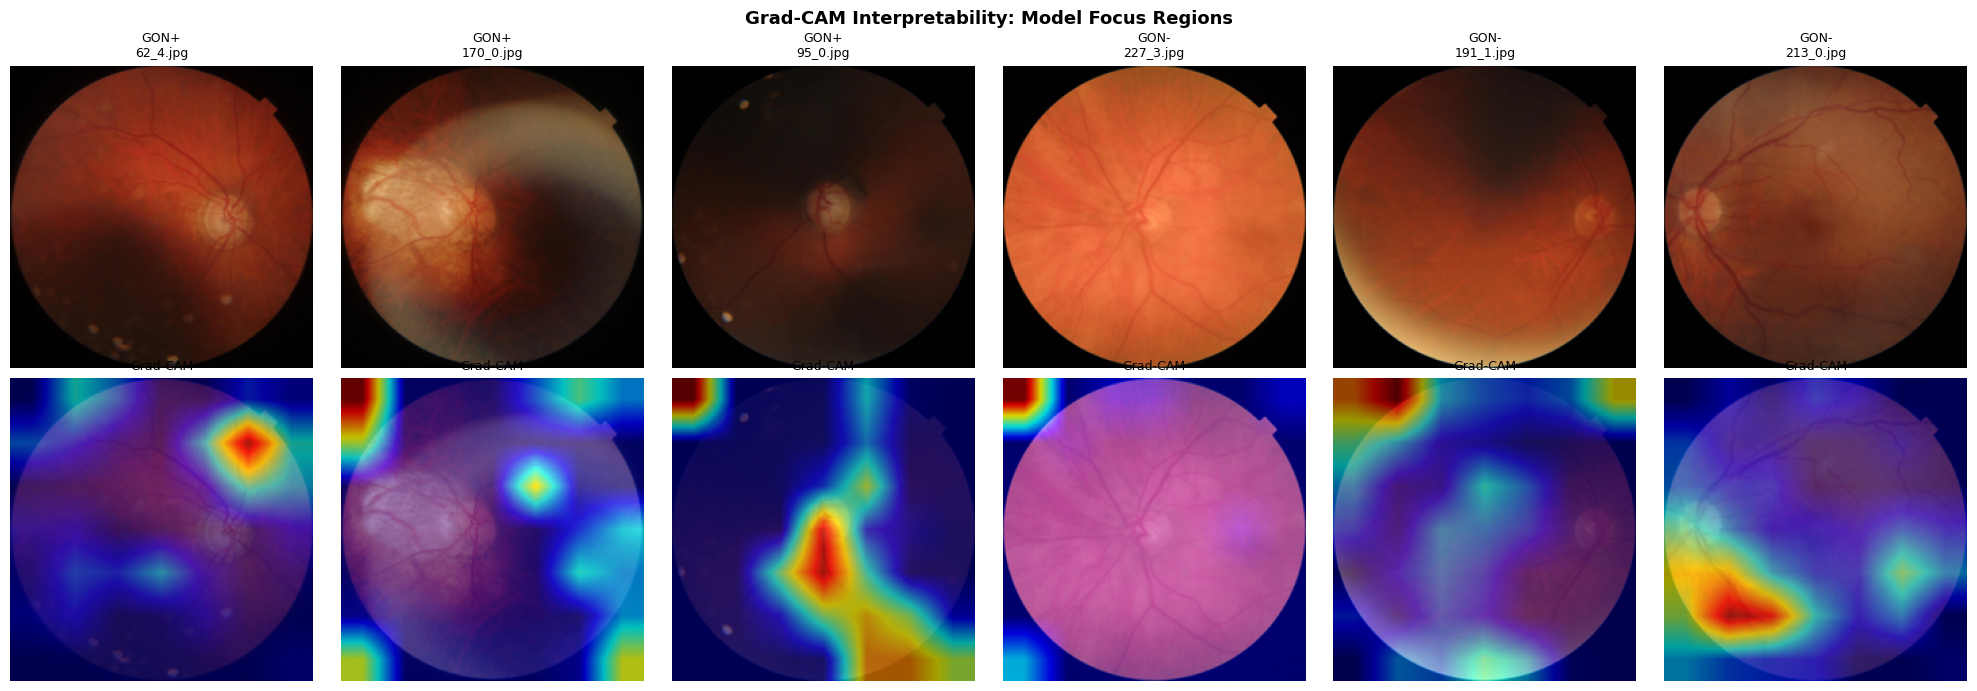

✅ Grad-CAM saved!


In [24]:
# Target the last convolutional layer of EfficientNet
target_layer = [model.conv_head]

# Pick 6 test images (3 GON+, 3 GON-)
test_df_reset = test_df.reset_index(drop=True)
gon_pos = test_df_reset[test_df_reset['label_num'] == 1].sample(3, random_state=42)
gon_neg = test_df_reset[test_df_reset['label_num'] == 0].sample(3, random_state=42)
sample_df = pd.concat([gon_pos, gon_neg]).reset_index(drop=True)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

with GradCAM(model=model, target_layers=target_layer) as cam:
    for i, row in sample_df.iterrows():
        # Load and preprocess image
        img_path = f"{images_path}/{row['Image Name']}"
        img_pil = Image.open(img_path).convert('RGB').resize((224, 224))
        img_np = np.array(img_pil) / 255.0

        input_tensor = val_transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)

        # Generate CAM for predicted class
        targets = [ClassifierOutputTarget(row['label_num'])]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        # Overlay heatmap on image
        visualization = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

        # Original image (top row)
        axes[0][i].imshow(img_pil)
        axes[0][i].set_title(f"{row['Label']}\n{row['Image Name']}", fontsize=9)
        axes[0][i].axis('off')

        # Grad-CAM heatmap (bottom row)
        axes[1][i].imshow(visualization)
        axes[1][i].set_title(f"Grad-CAM", fontsize=9)
        axes[1][i].axis('off')

axes[0][0].set_ylabel("Original", fontsize=11)
axes[1][0].set_ylabel("Grad-CAM", fontsize=11)
plt.suptitle("Grad-CAM Interpretability: Model Focus Regions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grad-CAM saved!")

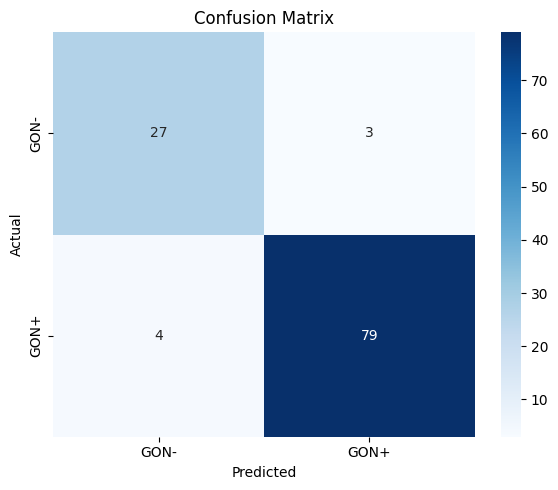

In [25]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['GON-', 'GON+'],
            yticklabels=['GON-', 'GON+'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

In [27]:
def quality_aware_predict(model, dataframe, images_dir, device, transform):
    model.eval()
    results = []

    with torch.no_grad():
        for _, row in dataframe.iterrows():
            # Load image
            img = Image.open(f"{images_dir}/{row['Image Name']}").convert('RGB')
            input_tensor = transform(img).unsqueeze(0).to(device)

            # Get raw model output
            output = torch.softmax(model(input_tensor), dim=1)
            raw_conf = output[0][1].item()  # confidence for GON+

            # Normalize quality score to 0-1
            quality = row['Quality Score'] / 10.0

            # Adjust confidence by quality score
            adjusted_conf = raw_conf * quality

            # Final prediction using adjusted confidence
            pred = 1 if adjusted_conf >= 0.5 else 0

            results.append({
                'Image Name': row['Image Name'],
                'True Label': row['label_num'],
                'Raw Confidence': round(raw_conf, 4),
                'Quality Score': row['Quality Score'],
                'Adjusted Confidence': round(adjusted_conf, 4),
                'Prediction': pred
            })

    return pd.DataFrame(results)

print("✅ Function defined!")

✅ Function defined!


In [28]:
from sklearn.metrics import roc_auc_score, classification_report

# Run quality-aware predictions
qa_results = quality_aware_predict(model, test_df, images_path, device, val_transform)

print("=== Quality-Aware Predictions (sample) ===")
print(qa_results.head(10).to_string(index=False))

# Compare standard vs quality-aware
standard_preds = qa_results['Prediction'].tolist()
true_labels = qa_results['True Label'].tolist()
adjusted_confs = qa_results['Adjusted Confidence'].tolist()

print("\n=== Standard Model Results ===")
print(classification_report(true_labels, test_preds, target_names=['GON-', 'GON+']))

print("\n=== Quality-Aware Model Results ===")
print(classification_report(true_labels, standard_preds, target_names=['GON-', 'GON+']))

print(f"Standard AUC-ROC:       {roc_auc_score(true_labels, test_preds):.4f}")
print(f"Quality-Aware AUC-ROC:  {roc_auc_score(true_labels, adjusted_confs):.4f}")

=== Quality-Aware Predictions (sample) ===
Image Name  True Label  Raw Confidence  Quality Score  Adjusted Confidence  Prediction
 170_0.jpg           1          0.9998           6.54               0.6539           1
 252_0.jpg           0          0.0000           6.59               0.0000           0
 127_0.jpg           1          0.3161           5.62               0.1777           0
 141_3.jpg           1          0.0020           5.92               0.0012           0
 147_1.jpg           1          1.0000           5.40               0.5400           1
 268_0.jpg           0          0.0047           5.34               0.0025           0
  60_0.jpg           1          0.9395           4.16               0.3908           0
  73_1.jpg           1          1.0000           6.78               0.6780           1
 219_2.jpg           0          0.0037           6.53               0.0024           0
 265_1.jpg           0          0.0001           5.29               0.0001           0


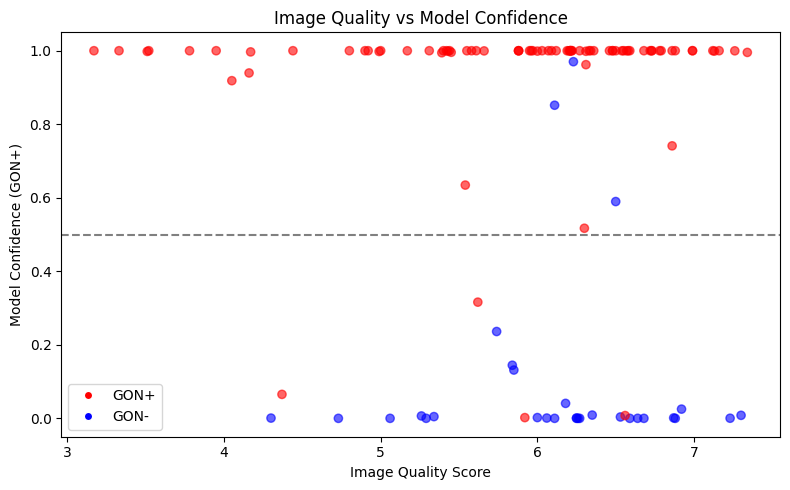

In [29]:
plt.figure(figsize=(8, 5))
colors = ['red' if l == 1 else 'blue' for l in qa_results['True Label']]
plt.scatter(qa_results['Quality Score'],
            qa_results['Raw Confidence'],
            c=colors, alpha=0.6, label='Raw Confidence')
plt.xlabel('Image Quality Score')
plt.ylabel('Model Confidence (GON+)')
plt.title('Image Quality vs Model Confidence')
plt.axhline(0.5, color='gray', linestyle='--', label='Decision threshold')
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w',
                   markerfacecolor='red', label='GON+'),
                   Line2D([0],[0], marker='o', color='w',
                   markerfacecolor='blue', label='GON-')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('/content/quality_vs_confidence.png', dpi=150)
plt.show()